In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import SimpleImputer

Učitati podatke za crno i bijelo vino koji se nalaze u CSV datotekama winequality-red.csv i winequality-white.csv u varijable red i white respektivno. Pri ovome postaviti parametar separator da bude znak tačka-zarez (;). U odgovarajućim DataFrame objektima dodati novu kolonu label koja će imati vrijednost 0 za podatke bijelog vina, a vrijednost 1 za podatke crnog vina. Nakon ovoga spojiti ih u jedan DataFrame objekat wine

In [7]:
bijelo = pd.read_csv('winequality-white.csv', sep=';')
crno = pd.read_csv('winequality-red.csv', sep=';')

bijelo['label'] = 0
crno['label'] = 1

wines = pd.concat([bijelo, crno], ignore_index=True)
print(wines.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  label  
0      8.8        6      0  
1      9.5        6      0  

Izvršiti prikaz osnovnih podataka spojenog skupa podataka korištenjem describe metode te nacrtati histograme korištenjem hist metode. Šta možete zaključiti o podacima?

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666     0.318633        5.443235   
std         1.296434          0.164636     0.145318        4.757804   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.250000        1.800000   
50%         7.000000          0.290000     0.310000        3.000000   
75%         7.700000          0.400000     0.390000        8.100000   
max        15.900000          1.580000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  6497.000000          6497.000000           6497.000000  6497.000000   
mean      0.056034            30.525319            115.744574     0.994697   
std       0.035034            17.749400             56.521855     0.002999   
min       0.009000             1.000000         

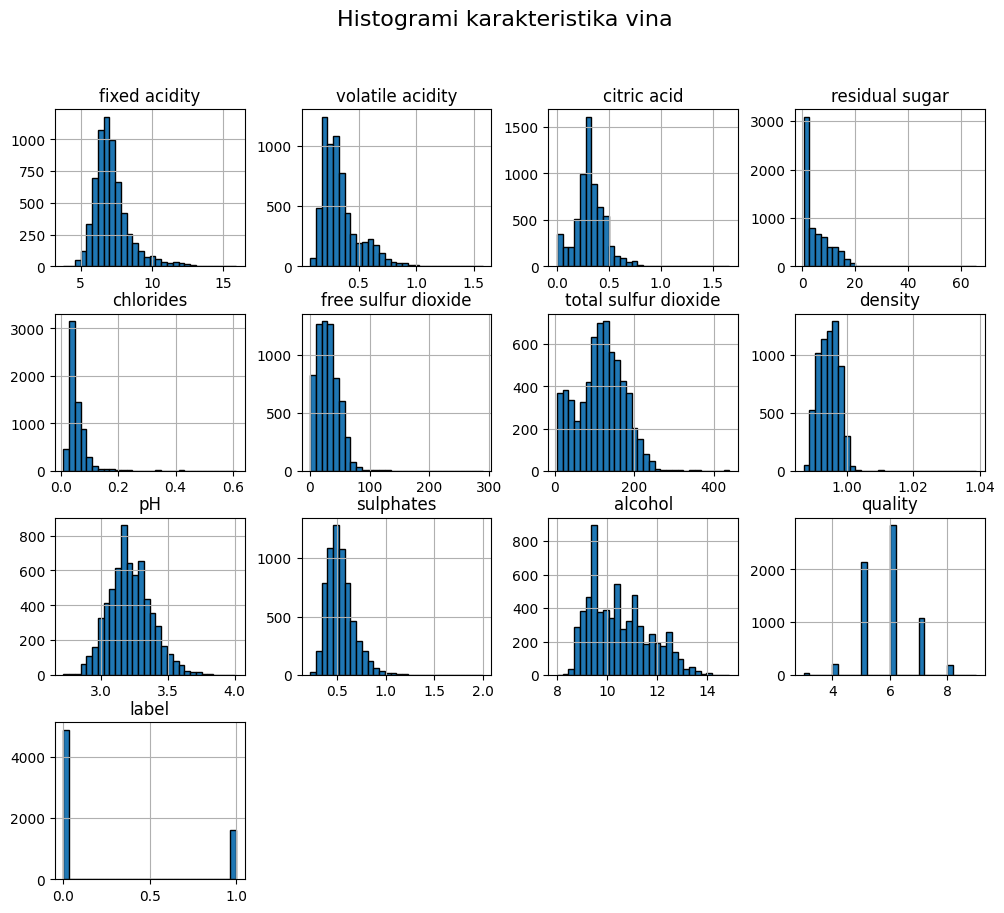

In [8]:
print(wines.describe())
wines.hist(figsize=(12,10), bins=30, edgecolor='black')
plt.suptitle("Histogrami karakteristika vina", fontsize=16)
plt.show()

Iz wines izdvojiti X - karakteristike i y - labele. Zatim korištenjem funkcije train_test_split podijeliti podatke na one za treniranje i one za testiranje pri čemu 20% podataka trebaju biti podaci za testiranje;

In [9]:
from sklearn.model_selection import train_test_split
X = wines.drop(columns=['label'])
y = wines['label']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Trening skup: {x_train.shape}, Test skup: {x_test.shape}")

Trening skup: (5197, 12), Test skup: (1300, 12)


Formirati sekvencijalni Keras model koji će imati 2 Dense sloja sa po 8 neurona i relu aktivacijskom
funkcijom. Prvom sloju kao input_shape parametar proslijediti vrijednost (12,) s obzirom na to da skup
podataka ima 12 značajki. Treći sloj, koji je u ovom slučaju izlazni sloj, postaviti da također bude Dense, ali
sa samo jednim neuronom;[link text](https://)

In [15]:
from keras import models
from keras import layers

model = models.Sequential()
model.add(layers.Dense(8, activation = 'relu', input_shape=(12,)))
model.add(layers.Dense(8, activation = 'relu'))
model.add(layers.Dense(1, activation = 'sigmoid'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 185 (740.00 B)

 Trainable params: 185 (740.00 B)

 Non-trainable params: 0 (0.00 B)

Kompajlirati model tako da koristi adam optimizator, za funkciju gubitka koristiti binary_crossentropy,
a kao metriku odabrati accuracy;

In [16]:
model.compile(optimizer = 'adam',
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

Model istrenirati na 20 epoha, sa veličinom batch-a 16. Kolika je postignuta tačnost, a kolika vrijednost funkcije
gubitka na kraju treniranja?

In [17]:
history = model.fit(x_train, y_train,
                    epochs = 20,
                    batch_size = 16,
                    validation_split = 0.2)

final_loss, final_acc = history.history['loss'][-1], history.history['accuracy'][-1]
print(f"Finalna tačnost (bez skaliranja): {final_acc:.4f}")
print(f"Finalni gubitak (bez skaliranja): {final_loss:.4f}")

Epoch 1/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8259 - loss: 0.4131 - val_accuracy: 0.9212 - val_loss: 0.2134
Epoch 2/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9276 - loss: 0.2066 - val_accuracy: 0.9423 - val_loss: 0.1857
Epoch 3/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9414 - loss: 0.1763 - val_accuracy: 0.9462 - val_loss: 0.1747
Epoch 4/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9383 - loss: 0.1698 - val_accuracy: 0.9423 - val_loss: 0.1650
Epoch 5/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9378 - loss: 0.1731 - val_accuracy: 0.9529 - val_loss: 0.1573
Epoch 6/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9442 - loss: 0.1692 - val_accuracy: 0.9558 - val_loss: 0.1500
Epoch 7/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9535 - loss: 0.1374 - val_accuracy: 0.9423 - val_loss: 0.1538
Epoch 8/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9452 - loss: 0.1503 - val_accuracy: 0.

Ponoviti postupak 1, no ovaj put prije treniranja izvršiti standardizaciju, odnosno skaliranje atributa korištenjem
StandardScaler objekat iz sklearn.preprocessing modula. Kolika je sada tačnost nakon treniranja?
Uporediti rezultate sa onim bez skaliranja;

In [18]:
from sklearn.preprocessing import StandardScaler

# Standardizacija podataka
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

# Ponovno formiranje i treniranje modela
model_scaled = models.Sequential()
model_scaled.add(layers.Dense(8, activation='relu', input_shape=(12,)))
model_scaled.add(layers.Dense(8, activation='relu'))
model_scaled.add(layers.Dense(1, activation='sigmoid'))

model_scaled.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

history_scaled = model_scaled.fit(X_train_scaled, y_train,
                                 epochs=20,
                                 batch_size=16,
                                 validation_split=0.2)

# Prikaz finalne tačnosti i gubitka sa skaliranjem
final_loss_scaled, final_acc_scaled = history_scaled.history['loss'][-1], history_scaled.history['accuracy'][-1]
print(f"Finalna tačnost (sa skaliranjem): {final_acc_scaled:.4f}")
print(f"Finalni gubitak (sa skaliranjem): {final_loss_scaled:.4f}")

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7829 - loss: 0.4038 - val_accuracy: 0.9269 - val_loss: 0.2464
Epoch 2/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9574 - loss: 0.1946 - val_accuracy: 0.9788 - val_loss: 0.1581
Epoch 3/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9866 - loss: 0.1118 - val_accuracy: 0.9865 - val_loss: 0.1119
Epoch 4/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9891 - loss: 0.0869 - val_accuracy: 0.9856 - val_loss: 0.0887
Epoch 5/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9900 - loss: 0.0620 - val_accuracy: 0.9875 - val_loss: 0.0753
Epoch 6/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9935 - loss: 0.0414 - val_accuracy: 0.9885 - val_loss: 0.0680
Epoch 7/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9935 - loss: 0.0343 - val_accuracy: 0.9885 - val_loss: 0.0641
Epoch 8/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9966 - loss: 0.0231 - val_accuracy: 0.9894 - val_

Model evaluirati nad testnim skupom podataka. Kolika je postignuta tačnost modela?

In [19]:
# Evaluacija modela sa skaliranim podacima na test skupu
test_loss, test_acc = model_scaled.evaluate(X_test_scaled, y_test)
print(f"Tačnost na test skupu: {test_acc:.4f}")
print(f"Gubitak na test skupu: {test_loss:.4f}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9940 - loss: 0.0187
Tačnost na test skupu: 0.9946
Gubitak na test skupu: 0.0325


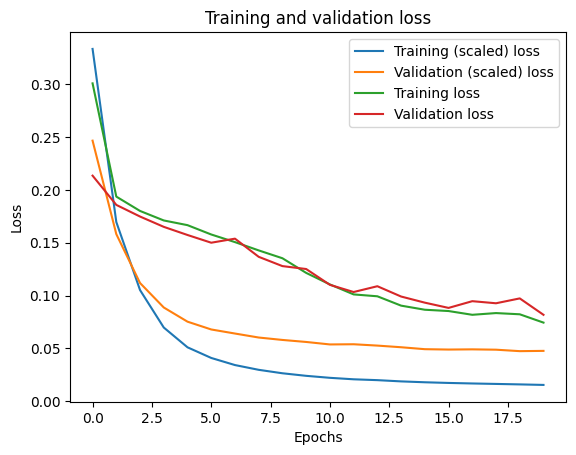

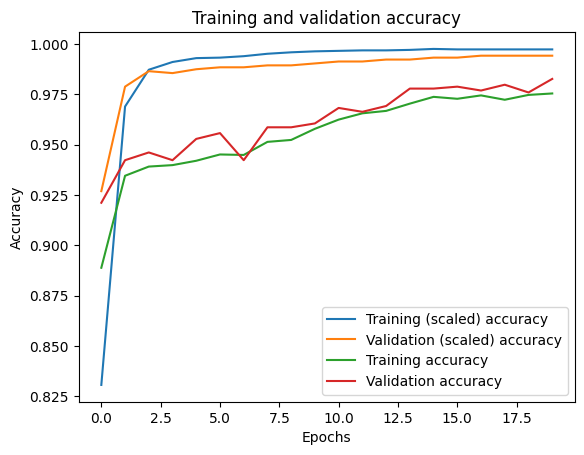

In [21]:
import matplotlib.pyplot as plt

# Prikaz gubitka tokom treniranja
plt.plot(history_scaled.history['loss'], label='Training (scaled) loss')
plt.plot(history_scaled.history['val_loss'], label='Validation (scaled) loss')
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Prikaz tačnosti tokom treniranja
plt.plot(history_scaled.history['accuracy'], label='Training (scaled) accuracy')
plt.plot(history_scaled.history['val_accuracy'], label='Validation (scaled) accuracy')
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
